# 📡 Separação e Análise dos Dados do PA

**Objetivo:** Carregar o arquivo `.mat` com os dados do amplificador de potência (PA GaN HEMT, 900 MHz, WCDMA 3,84 MHz), inspecionar os sinais, separar os conjuntos de **extração** e **validação**, e visualizar as principais características.

---
**Campos esperados no `.mat`:**
| Campo | Descrição |
|---|---|
| `in_extraction` | Sinal de entrada — conjunto de extração (treinamento) |
| `out_extraction` | Sinal de saída do PA — conjunto de extração |
| `in_validation` | Sinal de entrada — conjunto de validação |
| `out_validation` | Sinal de saída do PA — conjunto de validação |

> ⚙️ **Ajuste a célula de configuração abaixo antes de executar.**

## 0 · Configuração

In [1]:
# ─── EDITE AQUI ────────────────────────────────────────────────────────────
MAT_FILE = "in_out_SBRT2_direto.mat"   # caminho do arquivo .mat
FS_MHZ   = 61.44                        # taxa de amostragem [MHz]
# ────────────────────────────────────────────────────────────────────────────

# Nomes dos campos dentro do .mat (ajuste se diferentes)
CAMPO_IN_EXT  = "in_extraction"
CAMPO_OUT_EXT = "out_extraction"
CAMPO_IN_VAL  = "in_validation"
CAMPO_OUT_VAL = "out_validation"

## 1 · Importações

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2 · Carregamento do arquivo `.mat`

In [3]:
mat = sio.loadmat(MAT_FILE)

# Mostra todos os campos disponíveis
campos = [k for k in mat.keys() if not k.startswith("_")]
print("Campos encontrados no .mat:")
for c in campos:
    arr = mat[c]
    print(f"  {c:25s} → shape={arr.shape}  dtype={arr.dtype}")

Campos encontrados no .mat:
  in_extraction             → shape=(3221, 1)  dtype=complex128
  out_extraction            → shape=(3221, 1)  dtype=complex128
  out_validation            → shape=(2001, 1)  dtype=complex128
  in_validation             → shape=(2001, 1)  dtype=complex128


## 3 · Extração dos sinais

In [4]:
x_ext = mat[CAMPO_IN_EXT].flatten()
y_ext = mat[CAMPO_OUT_EXT].flatten()
x_val = mat[CAMPO_IN_VAL].flatten()
y_val = mat[CAMPO_OUT_VAL].flatten()

N_ext = len(x_ext)
N_val = len(x_val)
T_ext_us = N_ext / FS_MHZ          # duração em µs
T_val_us = N_val / FS_MHZ

print(f"{'Conjunto':<20} {'Amostras':>10} {'Duração':>12} {'Dtype':>12}")
print("-" * 58)
print(f"{'Extração (x)':20} {N_ext:>10,} {T_ext_us:>10.1f} µs {str(x_ext.dtype):>12}")
print(f"{'Extração (y)':20} {len(y_ext):>10,} {T_ext_us:>10.1f} µs {str(y_ext.dtype):>12}")
print(f"{'Validação (x)':20} {N_val:>10,} {T_val_us:>10.1f} µs {str(x_val.dtype):>12}")
print(f"{'Validação (y)':20} {len(y_val):>10,} {T_val_us:>10.1f} µs {str(y_val.dtype):>12}")
print()
print(f"Sinal complexo? entrada={np.iscomplexobj(x_ext)}  saída={np.iscomplexobj(y_ext)}")

Conjunto               Amostras      Duração        Dtype
----------------------------------------------------------
Extração (x)              3,221       52.4 µs   complex128
Extração (y)              3,221       52.4 µs   complex128
Validação (x)             2,001       32.6 µs   complex128
Validação (y)             2,001       32.6 µs   complex128

Sinal complexo? entrada=True  saída=True


## 4 · Estatísticas básicas

In [5]:
def stats(nome, sinal):
    amp = np.abs(sinal)
    print(f"\n{nome}")
    print(f"  |x| → min={amp.min():.4f}  max={amp.max():.4f}  "
          f"mean={amp.mean():.4f}  std={amp.std():.4f}")
    print(f"  PAPR = {10*np.log10(amp.max()**2 / np.mean(amp**2)):.2f} dB")

stats("Extração — entrada  (x_ext)", x_ext)
stats("Extração — saída    (y_ext)", y_ext)
stats("Validação — entrada (x_val)", x_val)
stats("Validação — saída   (y_val)", y_val)


Extração — entrada  (x_ext)
  |x| → min=0.0121  max=1.4534  mean=0.8194  std=0.2492
  PAPR = 4.59 dB

Extração — saída    (y_ext)
  |x| → min=0.0101  max=1.1626  mean=0.7127  std=0.2011
  PAPR = 3.92 dB

Validação — entrada (x_val)
  |x| → min=0.0401  max=1.4074  mean=0.8238  std=0.2309
  PAPR = 4.32 dB

Validação — saída   (y_val)
  |x| → min=0.0159  max=1.1358  mean=0.7208  std=0.1845
  PAPR = 3.67 dB


## 5 · Visualização no domínio do tempo (envoltória)

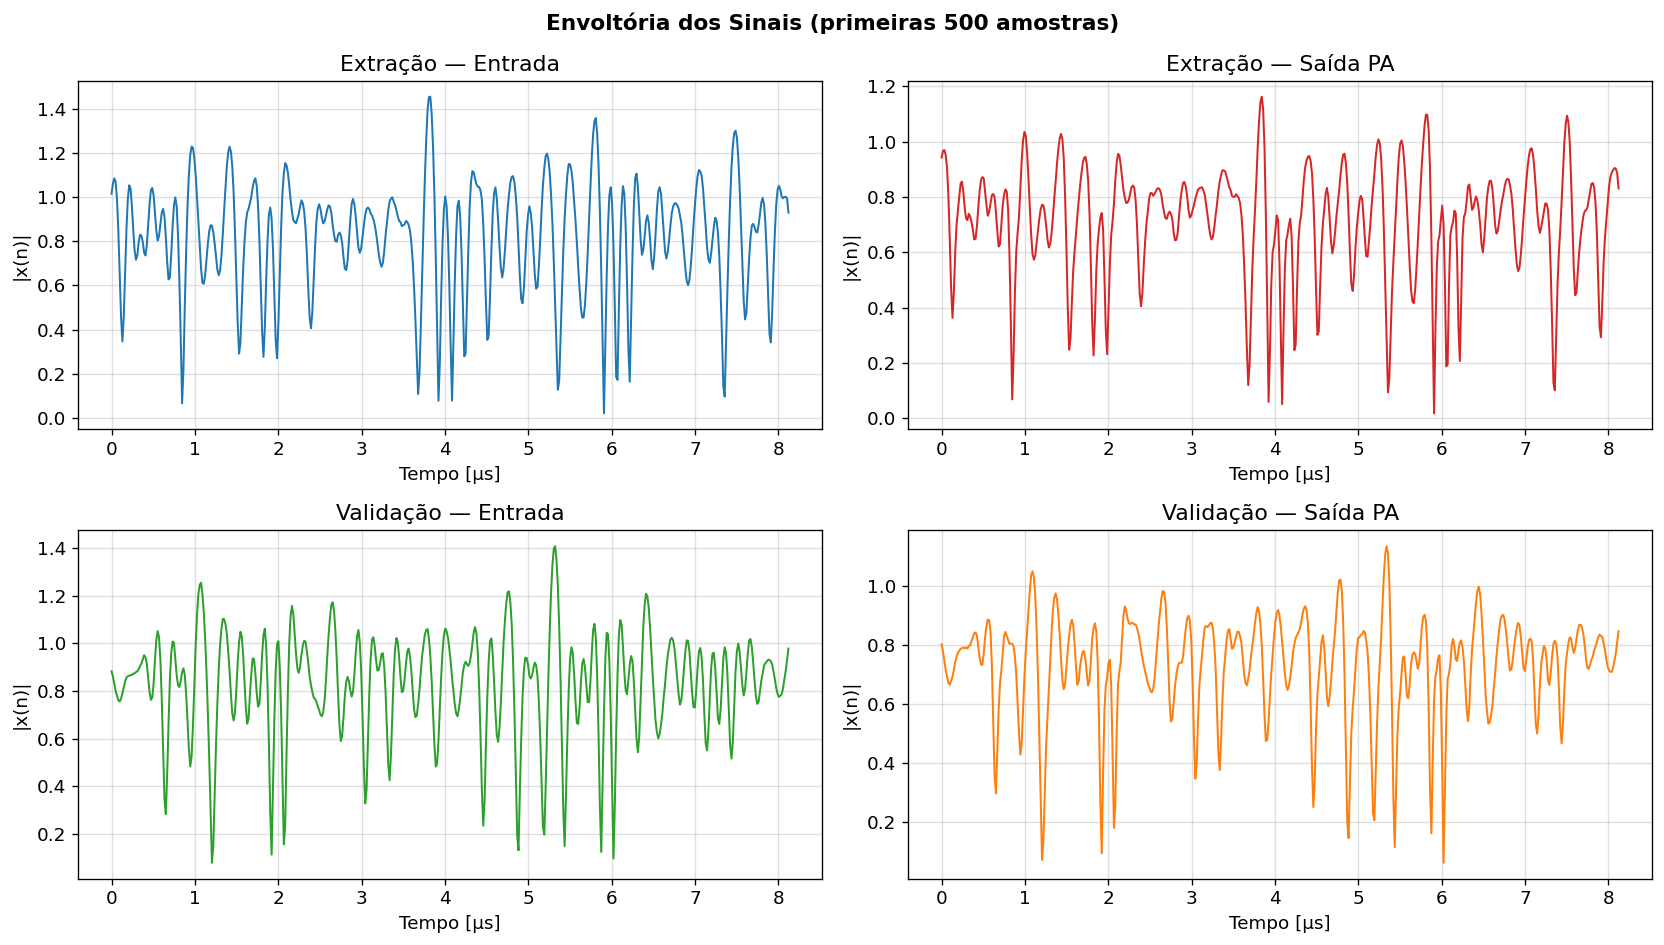

In [ ]:
N_plot = 500   # amostras exibidas
t = np.arange(N_plot) / FS_MHZ   # tempo em µs

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
fig.suptitle("Envoltória dos Sinais (primeiras 500 amostras)", fontsize=13, fontweight="bold")

pares = [
    (axes[0, 0], x_ext, "Extração — Entrada",  "#1f77b4"),
    (axes[0, 1], y_ext, "Extração — Saída PA",  "#d62728"),
    (axes[1, 0], x_val, "Validação — Entrada",  "#2ca02c"),
    (axes[1, 1], y_val, "Validação — Saída PA", "#ff7f0e"),
]

for ax, sinal, titulo, cor in pares:
    ax.plot(t, np.abs(sinal[:N_plot]), color=cor, lw=1.2)
    ax.set_title(titulo)
    ax.set_xlabel("Tempo [µs]")
    ax.set_ylabel("|x(n)|")

plt.tight_layout()
# plt.savefig("tempo_envoltoria.png", bbox_inches="tight")
plt.show()

## 6 · Curva AM/AM e AM/PM (não-linearidade do PA)

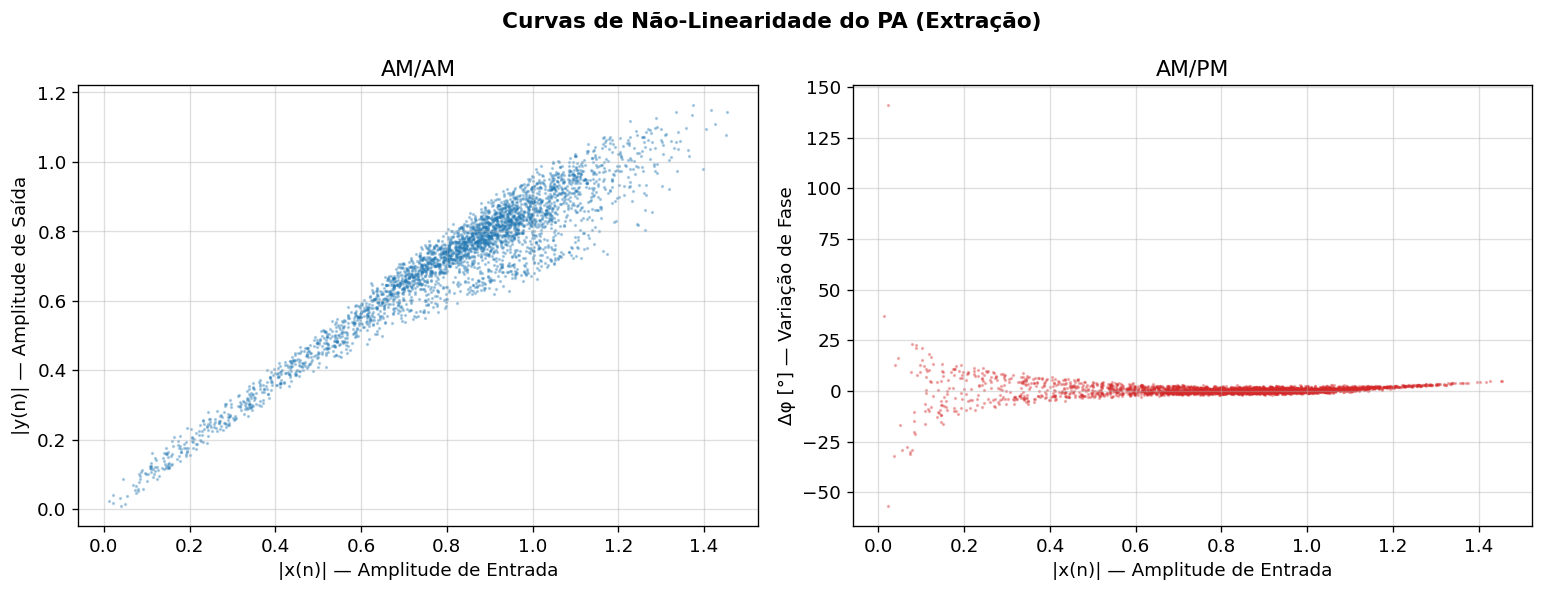

In [ ]:
amp_in  = np.abs(x_ext)
amp_out = np.abs(y_ext)
fase_pm = np.angle(y_ext / x_ext, deg=True)   # variação de fase

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Curvas de Não-Linearidade do PA (Extração)",
             fontsize=13, fontweight="bold")

# AM/AM
ax1.scatter(amp_in, amp_out, s=1, alpha=0.3, color="#1f77b4")
ax1.set_title("AM/AM")
ax1.set_xlabel("|x(n)| — Amplitude de Entrada")
ax1.set_ylabel("|y(n)| — Amplitude de Saída")

# AM/PM
ax2.scatter(amp_in, fase_pm, s=1, alpha=0.3, color="#d62728")
ax2.set_title("AM/PM")
ax2.set_xlabel("|x(n)| — Amplitude de Entrada")
ax2.set_ylabel("Δφ [°] — Variação de Fase")

plt.tight_layout()
# plt.savefig("amam_ampm.png", bbox_inches="tight")
plt.show()

## 7 · Espectro de Potência (PSD via Welch)

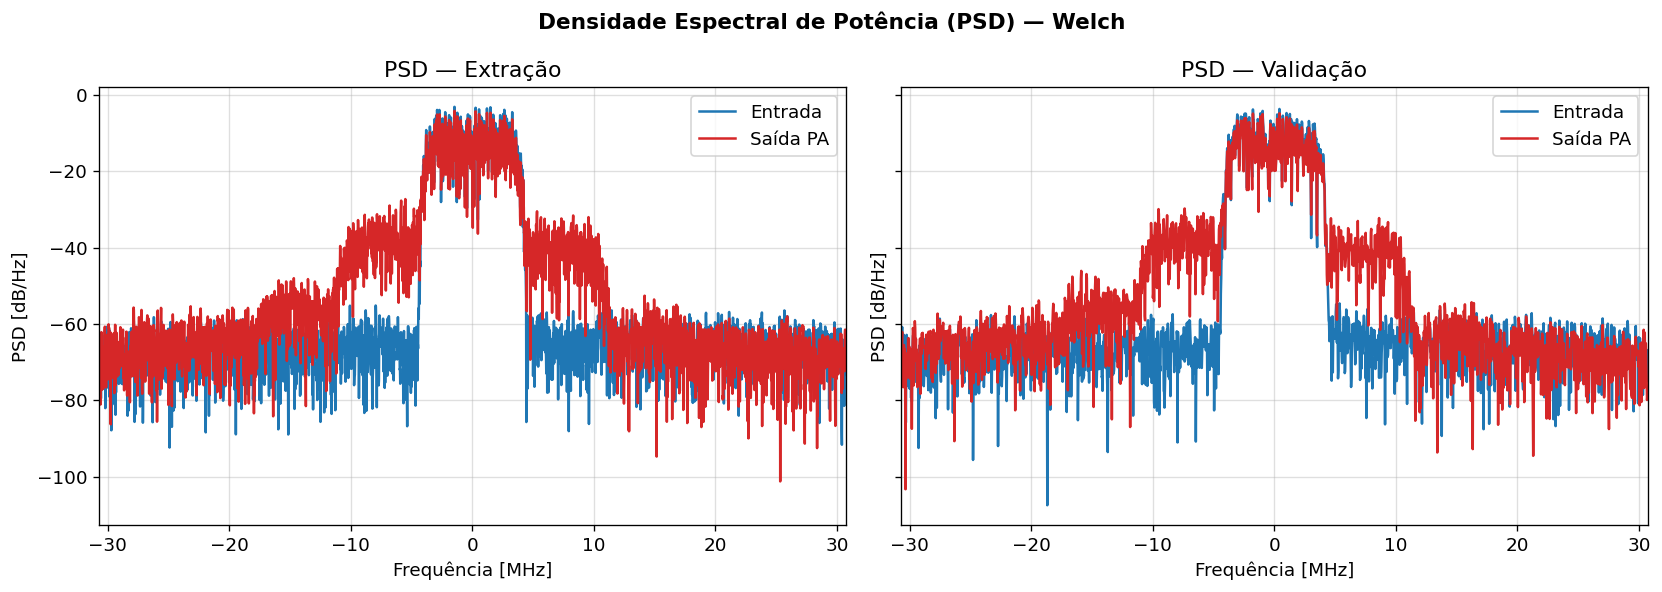

In [ ]:
def psd_welch(sinal, fs, nperseg=4096):
    """Retorna (frequência em MHz, PSD em dB/Hz) centralizada em 0."""
    nperseg = min(nperseg, len(sinal))
    f, Pxx = welch(sinal, fs=fs, window="hann",
                   nperseg=nperseg, noverlap=nperseg // 2,
                   return_onesided=False)
    f   = np.fft.fftshift(f)
    Pxx = np.fft.fftshift(Pxx)
    return f, 10 * np.log10(Pxx + 1e-20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Densidade Espectral de Potência (PSD) — Welch",
             fontsize=13, fontweight="bold")

for ax, (sx, sy, titulo) in zip(
    axes,
    [(x_ext, y_ext, "Extração"), (x_val, y_val, "Validação")]
):
    f_in,  p_in  = psd_welch(sx, FS_MHZ)
    f_out, p_out = psd_welch(sy, FS_MHZ)
    ax.plot(f_in,  p_in,  lw=1.5, label="Entrada",   color="#1f77b4")
    ax.plot(f_out, p_out, lw=1.5, label="Saída PA",  color="#d62728")
    ax.set_title(f"PSD — {titulo}")
    ax.set_xlabel("Frequência [MHz]")
    ax.set_ylabel("PSD [dB/Hz]")
    ax.set_xlim(-FS_MHZ / 2, FS_MHZ / 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.legend()

plt.tight_layout()
# plt.savefig("psd_entrada_saida.png", bbox_inches="tight")
plt.show()

## 8 · Constelação IQ (scatter)

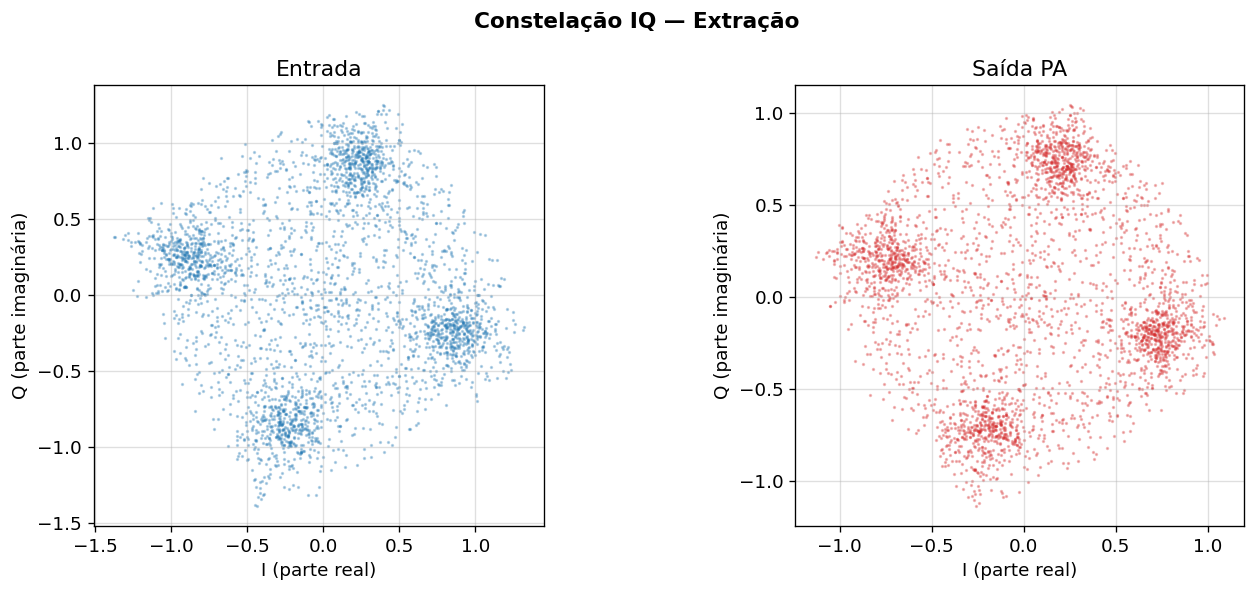

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Constelação IQ — Extração", fontsize=13, fontweight="bold")

for ax, sinal, titulo, cor in [
    (axes[0], x_ext, "Entrada",  "#1f77b4"),
    (axes[1], y_ext, "Saída PA", "#d62728"),
]:
    ax.scatter(sinal.real, sinal.imag, s=1, alpha=0.3, color=cor)
    ax.set_title(titulo)
    ax.set_xlabel("I (parte real)")
    ax.set_ylabel("Q (parte imaginária)")
    ax.set_aspect("equal")

plt.tight_layout()
# plt.savefig("constelacao_iq.png", bbox_inches="tight")
plt.show()

---
## Resumo

| Variável | Conteúdo |
|---|---|
| `x_ext` | Entrada — extração (treinamento) |
| `y_ext` | Saída PA — extração |
| `x_val` | Entrada — validação |
| `y_val` | Saída PA — validação |

Esses vetores estão prontos para uso no script `analise_espectral_p0_p1_p2.py`.

Basta apontar `DATA_FILE = "dados_pa.mat"` no script de análise espectral.